In [10]:
from google.colab import files

print("Envie o vídeo do pêndulo (.mp4)")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]
print("Arquivo carregado:", video_path)

Envie o vídeo do pêndulo (.mp4)


Saving Pêndulo simples - vídeo.mp4 to Pêndulo simples - vídeo (2).mp4
Arquivo carregado: Pêndulo simples - vídeo (2).mp4


In [11]:
!pip install opencv-python numpy pandas matplotlib scipy

CSV salvo em: pendulo_movimento/posicao_pendulo.csv
Desvio padrão em x: 73.02 px, em y: 4.57 px, razão y/x = 0.063


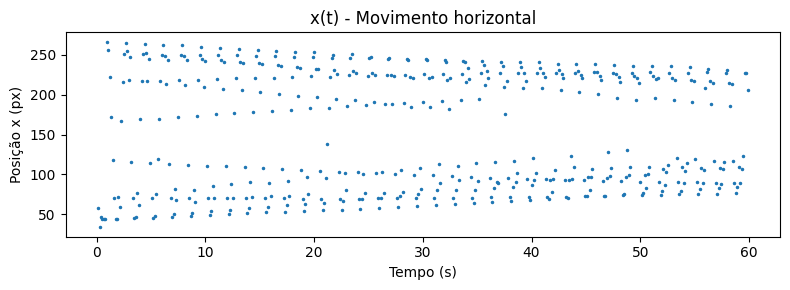

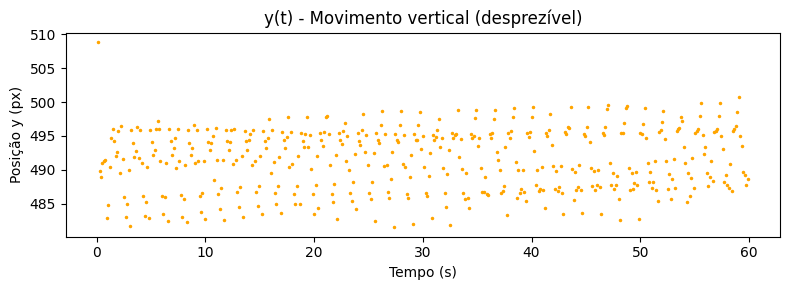

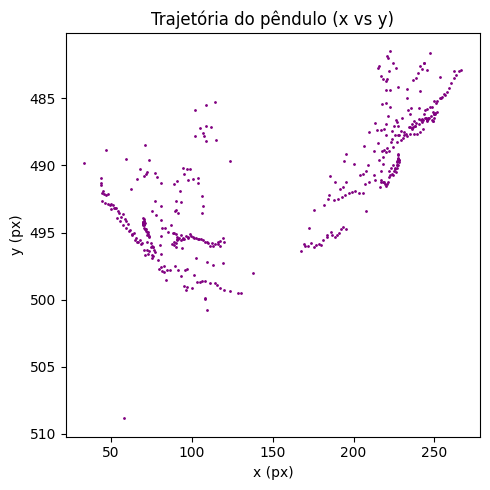

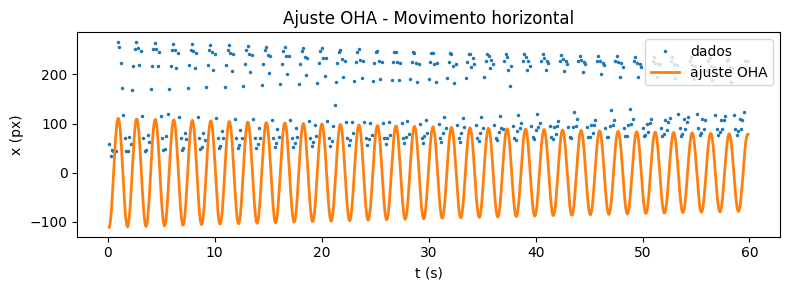


Parâmetros do OHA:
Amplitude (A) ............: 111.704 px
Coef. de amortecimento (b): 0.00585 s⁻¹
Frequência angular (ω) ....: 3.6295 rad/s
Fase (φ) .................: 2.735 rad
Fator de qualidade (Q=ω/b): 620.1


In [12]:
# Análise do pêndulo: detecção por MOVIMENTO

import cv2, os, math, json
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt

out_dir = "pendulo_movimento"
os.makedirs(out_dir, exist_ok=True)

process_seconds = 60.0
target_width = 320
target_proc_fps = 8.0
alpha_bg = 0.2

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise SystemExit("Erro: não foi possível abrir o vídeo.")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps
max_frames = int(min(frame_count, math.ceil(min(process_seconds, duration) * fps)))

sample_rate = max(1, int(round(fps / target_proc_fps)))

bg_accum = None
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
results = []

ret, frame = cap.read()
if not ret:
    raise SystemExit("Erro ao ler o primeiro frame.")
h0, w0 = frame.shape[:2]
scale = target_width / float(w0)
new_w, new_h = int(w0 * scale), int(h0 * scale)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

frame_idx = 0
while frame_idx < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % sample_rate != 0:
        frame_idx += 1
        continue

    frame = cv2.resize(frame, (new_w, new_h))
    t_s = frame_idx / fps

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)

    if bg_accum is None:
        bg_accum = gray.astype("float")
        cx, cy = np.nan, np.nan
    else:
        cv2.accumulateWeighted(gray, bg_accum, alpha_bg)
        bg_uint = bg_accum.astype("uint8")
        diff = cv2.absdiff(gray, bg_uint)
        _, motion_mask = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)

        contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cx, cy = np.nan, np.nan
        if contours:
            c = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c) > 20:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    cx = M["m10"] / M["m00"]
                    cy = M["m01"] / M["m00"]

    results.append((frame_idx, t_s, cx, cy))
    frame_idx += 1

cap.release()

df = pd.DataFrame(results, columns=["frame", "t_s", "x", "y"])
csv_path = os.path.join(out_dir, "posicao_pendulo.csv")
df.to_csv(csv_path, index=False)
print("CSV salvo em:", csv_path)

x_std = np.nanstd(df["x"])
y_std = np.nanstd(df["y"])
print(f"Desvio padrão em x: {x_std:.2f} px, em y: {y_std:.2f} px, razão y/x = {y_std/x_std:.3f}")

plt.figure(figsize=(8,3))
plt.plot(df["t_s"], df["x"], '.', markersize=3)
plt.title("x(t) - Movimento horizontal")
plt.xlabel("Tempo (s)")
plt.ylabel("Posição x (px)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(df["t_s"], df["y"], '.', color="orange", markersize=3)
plt.title("y(t) - Movimento vertical (desprezível)")
plt.xlabel("Tempo (s)")
plt.ylabel("Posição y (px)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.plot(df["x"], df["y"], '.', markersize=2, color="purple")
plt.title("Trajetória do pêndulo (x vs y)")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

def oha(t, A, b, omega, phi):
    return A * np.exp(-b * t) * np.cos(omega * t + phi)

mask = ~np.isnan(df["x"])
t = df.loc[mask, "t_s"].to_numpy()
x = df.loc[mask, "x"].to_numpy()

x_detr = x - np.mean(x)
N = len(x_detr)
dt = np.mean(np.diff(t)) if len(t) > 1 else 1.0/fps
yf = np.abs(rfft(x_detr))
xf = rfftfreq(N, d=dt)
omega0 = 2*np.pi*xf[np.argmax(yf[1:])+1] if len(xf)>1 else 2*np.pi*0.5

A0 = (np.nanmax(x) - np.nanmin(x)) / 2
b0 = 0.02
phi0 = 0.0
p0 = [A0, b0, omega0, phi0]

popt, pcov = curve_fit(oha, t, x, p0=p0, maxfev=20000)
A, b, omega, phi = popt
Q = omega / b

t_fit = np.linspace(t[0], t[-1], 800)
x_fit = oha(t_fit, *popt)
plt.figure(figsize=(8,3))
plt.plot(t, x, '.', markersize=3, label="dados")
plt.plot(t_fit, x_fit, label="ajuste OHA", linewidth=2)
plt.title("Ajuste OHA - Movimento horizontal")
plt.xlabel("t (s)")
plt.ylabel("x (px)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nParâmetros do OHA:")
print(f"Amplitude (A) ............: {A:.3f} px")
print(f"Coef. de amortecimento (b): {b:.5f} s⁻¹")
print(f"Frequência angular (ω) ....: {omega:.4f} rad/s")
print(f"Fase (φ) .................: {phi:.3f} rad")
print(f"Fator de qualidade (Q=ω/b): {Q:.1f}")


In [13]:
from google.colab import files
files.download("pendulo_movimento/posicao_pendulo.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>